# Hồi quy tuyến tính đa biến dự đoán cường độ chịu nén bê tông

Xây dựng mô hình dự đoán **cường độ chịu nén** (`strength`, MPa) từ thành phần cấp phối và tuổi bê tông.

## 1. Lý thuyết hồi quy tuyến tính đa biến

Với $k$ biến đầu vào, mô hình hồi quy tuyến tính đa biến có dạng:

$$
y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_kx_k + \varepsilon.
$$

Trong đó, $y$ là biến mục tiêu, $\beta_0$ là hệ số chặn, $\beta_j$ cho biết $y$ thay đổi trung bình bao nhiêu khi $x_j$ tăng một đơn vị **và các biến khác được giữ cố định**, còn $\varepsilon$ là sai số chưa được mô hình giải thích.

Phương pháp bình phương tối thiểu (OLS) chọn các hệ số sao cho tổng bình phương phần dư nhỏ nhất:

$$
\min_{\beta_0,\ldots,\beta_k}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2.
$$

Các chỉ số sử dụng trong notebook:

- $R^2$: tỷ lệ biến thiên của `strength` được mô hình giải thích; càng gần 1 càng cao.
- Adjusted $R^2$: hiệu chỉnh $R^2$ theo số biến, hạn chế việc thêm biến không cần thiết.
- RMSE (MPa): căn bậc hai sai số bình phương trung bình, phạt mạnh sai số lớn.
- MAE (MPa): sai số tuyệt đối trung bình, dễ diễn giải trực tiếp.
- p-value của hệ số: với mức ý nghĩa 5%, p-value nhỏ hơn 0,05 là bằng chứng hệ số khác 0 sau khi đã kiểm soát các biến còn lại.

Các giả định cơ bản gồm: quan hệ gần tuyến tính; phần dư gần phân phối chuẩn; phương sai phần dư không đổi; và không có đa cộng tuyến nghiêm trọng. Notebook kiểm tra bằng đồ thị phần dư, Q-Q plot, histogram, kiểm định Jarque–Bera, kiểm định Breusch–Pagan và VIF.

### Ví dụ nhỏ với dữ liệu thật: `strength` theo `water` và `cement`

Ví dụ mô tả dưới đây dùng toàn bộ dữ liệu để minh họa cách đọc hệ số, không dùng để báo cáo khả năng dự đoán. Hai biến có đơn vị kg/m³; biến mục tiêu có đơn vị MPa.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera

RANDOM_STATE = 42
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

Đã nạp các thư viện cần thiết và cố định `RANDOM_STATE = 42` để kết quả chia dữ liệu có thể lặp lại.

### Xác định đường dẫn dự án và tạo các thư mục đầu ra

In [2]:
project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

data_path = project_root / "data" / "processed" / "cleaned.csv"
figures_dir = project_root / "figures"
tables_dir = project_root / "tables"
models_dir = project_root / "models"

for output_dir in [figures_dir, tables_dir, models_dir]:
    output_dir.mkdir(parents=True, exist_ok=True)


### Đọc dữ liệu và kiểm tra tên cột thực tế

In [3]:
df = pd.read_csv(data_path)

print(f"Kích thước dữ liệu: {df.shape[0]} dòng × {df.shape[1]} cột")
print("Các cột thực tế:")
print(df.columns.tolist())
display(df.head())

Kích thước dữ liệu: 1005 dòng × 17 cột
Các cột thực tế:
['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age', 'strength', 'log_age', 'w_c', 'age_group', 'scm_type', 'strength_level', 'outlier_iqr_any', 'outlier_zscore_any', 'outlier_mad_any']


,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength,log_age,w_c,age_group,scm_type,strength_level,outlier_iqr_any,outlier_zscore_any,outlier_mad_any
0,540.0000,0.0000,0.0000,162.0000,2.5000,"1,040.0000",676.0000,28,79.9861,3.3673,0.3000,Tiêu chuẩn (8–28 ngày),Không SCM,Cao,True,False,False
1,540.0000,0.0000,0.0000,162.0000,2.5000,"1,055.0000",676.0000,28,61.8874,3.3673,0.3000,Tiêu chuẩn (8–28 ngày),Không SCM,Cao,False,False,False
2,332.5000,142.5000,0.0000,228.0000,0.0000,932.0000,594.0000,270,40.2695,5.6021,0.6857,Dài ngày (>28 ngày),Chỉ slag,Trung bình,True,True,True
3,332.5000,142.5000,0.0000,228.0000,0.0000,932.0000,594.0000,365,41.0528,5.9026,0.6857,Dài ngày (>28 ngày),Chỉ slag,Trung bình,True,True,True
4,198.6000,132.4000,0.0000,192.0000,0.0000,978.4000,825.5000,360,44.2961,5.8889,0.9668,Dài ngày (>28 ngày),Chỉ slag,Trung bình,True,True,True


Dữ liệu có 1.005 quan sát. Các biến số cần thiết đều có mặt; các cột phân nhóm và cờ ngoại lệ chỉ phục vụ EDA nên không được đưa vào mô hình.

### Kiểm tra các cột bắt buộc và dữ liệu thiếu

In [4]:
required_columns = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_agg", "fine_agg", "age", "strength", "log_age", "w_c",
]
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Thiếu cột bắt buộc: {missing_columns}")

missing_values = df[required_columns].isna().sum()
print("Số giá trị thiếu trong các cột dùng cho phân tích:")
display(missing_values.to_frame("so_gia_tri_thieu"))

Số giá trị thiếu trong các cột dùng cho phân tích:


,so_gia_tri_thieu
cement,0
slag,0
fly_ash,0
water,0
superplasticizer,0
coarse_agg,0
fine_agg,0
age,0
strength,0
log_age,0


Không có giá trị thiếu trong các cột dùng cho hồi quy, vì vậy không cần điền khuyết hay loại thêm quan sát.

### Ước lượng ví dụ hai biến

In [5]:
example_X = sm.add_constant(df[["water", "cement"]], has_constant="add")
example_model = sm.OLS(df["strength"], example_X).fit()

example_table = pd.DataFrame({
    "he_so": example_model.params,
    "p_value": example_model.pvalues,
})
display(example_table)
print(f"R² của ví dụ: {example_model.rsquared:.4f}")

,he_so,p_value
const,48.3426,0.0000
water,-0.1852,0.0000
cement,0.0741,0.0000


R² của ví dụ: 0.2972


Kết quả thật cho phương trình minh họa là:

$$
\widehat{strength}=48{,}343-0{,}185\,water+0{,}074\,cement.
$$

Nếu lượng xi măng giữ nguyên, tăng 1 kg/m³ nước liên hệ với mức giảm trung bình khoảng 0,185 MPa. Nếu lượng nước giữ nguyên, tăng 1 kg/m³ xi măng liên hệ với mức tăng trung bình khoảng 0,074 MPa. Hai hệ số đều có p-value rất nhỏ, nhưng $R^2$ chỉ khoảng 0,297 nên hai biến này chưa mô tả đầy đủ cường độ.

## 2. Chuẩn bị dữ liệu

Dữ liệu được chia ngẫu nhiên 80% train và 20% test. Cùng một chỉ số dòng được dùng cho cả hai mô hình để so sánh công bằng.

In [6]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

train_df = df.loc[train_idx].copy()
test_df = df.loc[test_idx].copy()

print(f"Tập train: {train_df.shape[0]} dòng")
print(f"Tập test : {test_df.shape[0]} dòng")

Tập train: 804 dòng
Tập test : 201 dòng


Tập train có 804 dòng và tập test có 201 dòng. Tập test chỉ được dùng để đánh giá sau khi mô hình đã được ước lượng trên tập train.

## 3. Hàm tính chỉ số đánh giá

Hàm dưới đây tính bốn chỉ số theo cùng một công thức cho từng mô hình và từng tập dữ liệu.

In [7]:
def adjusted_r2(r2, n_samples, n_predictors):
    return 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_predictors - 1)


def evaluate_model(model, data, feature_names, split_name, model_name):
    X = sm.add_constant(data[feature_names], has_constant="add")
    actual = data["strength"]
    predicted = model.predict(X)
    r2 = r2_score(actual, predicted)
    return {
        "model": model_name,
        "set": split_name,
        "R2": r2,
        "Adjusted_R2": adjusted_r2(r2, len(data), len(feature_names)),
        "RMSE_MPa": np.sqrt(mean_squared_error(actual, predicted)),
        "MAE_MPa": mean_absolute_error(actual, predicted),
    }

Hàm trả về một dòng kết quả chuẩn hóa, giúp tránh lặp code và giảm nguy cơ tính hai mô hình theo cách khác nhau.

## 4. Mô hình 1 – Baseline

Mô hình cơ sở sử dụng 7 thành phần cấp phối và tuổi bê tông (`age`).

In [8]:
features_model_1 = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_agg", "fine_agg", "age",
]

X_train_1 = sm.add_constant(train_df[features_model_1], has_constant="add")
model_1 = sm.OLS(train_df["strength"], X_train_1).fit()

Mô hình 1 đã được ước lượng chỉ trên tập train bằng OLS.

### Bảng kết quả OLS của mô hình 1

In [9]:
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:               strength   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     155.3
Date:                Sat, 10 Oct 2026   Prob (F-statistic):          8.27e-157
Time:                        13:46:14   Log-Likelihood:                -2992.3
No. Observations:                 804   AIC:                             6003.
Df Residuals:                     795   BIC:                             6045.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -23.2328     28.872  

Bảng OLS cho thấy `cement`, `slag`, `fly_ash`, `water`, `superplasticizer` và `age` có ý nghĩa ở mức 5%; `coarse_agg` và `fine_agg` chưa có ý nghĩa thống kê trong mô hình này.

### Chỉ số train và test của mô hình 1

In [10]:
metrics_model_1 = pd.DataFrame([
    evaluate_model(model_1, train_df, features_model_1, "train", "Mô hình 1: age"),
    evaluate_model(model_1, test_df, features_model_1, "test", "Mô hình 1: age"),
])
display(metrics_model_1)

,model,set,R2,Adjusted_R2,RMSE_MPa,MAE_MPa
0,Mô hình 1: age,train,0.6098,0.6059,10.0025,7.9606
1,Mô hình 1: age,test,0.5801,0.5626,11.1922,8.8960


Mô hình baseline đạt $R^2$ train khoảng 0,610 và $R^2$ test khoảng 0,580. RMSE test khoảng 11,19 MPa, cho thấy quan hệ tuyến tính trực tiếp theo `age` còn bỏ sót dạng tăng nhanh lúc đầu và chậm dần về sau.

## 5. Mô hình 2 – Cải tiến

Mô hình ứng viên thay `age` bằng `log_age` và thêm tỷ lệ nước/xi măng `w_c`. Trước khi chốt tập biến, VIF được dùng để kiểm tra đa cộng tuyến.

In [11]:
features_model_2_candidate = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_agg", "fine_agg", "log_age", "w_c",
]

Danh sách ứng viên chứa đúng các biến cấp phối, tuổi logarit và tỷ lệ nước/xi măng; không chứa `age` hay `strength_level`.

### Hàm tính VIF

In [12]:
def calculate_vif(data, feature_names):
    X = sm.add_constant(data[feature_names], has_constant="add")
    rows = []
    for position, feature in enumerate(X.columns):
        if feature == "const":
            continue
        rows.append({
            "variable": feature,
            "VIF": variance_inflation_factor(X.values, position),
        })
    return pd.DataFrame(rows).sort_values("VIF", ascending=False).reset_index(drop=True)

VIF đo mức một biến đầu vào được giải thích bởi các biến còn lại. Quy ước thực hành trong notebook: VIF trên 10 là dấu hiệu đa cộng tuyến mạnh cần xem xét.

### VIF của tập biến ứng viên

In [13]:
vif_candidate = calculate_vif(train_df, features_model_2_candidate)
display(vif_candidate)

cement_wc_correlation = train_df[["cement", "w_c"]].corr().iloc[0, 1]
print(f"Tương quan cement – w_c: {cement_wc_correlation:.4f}")

,variable,VIF
0,cement,11.9775
1,water,7.4348
2,slag,7.2588
3,fine_agg,7.0746
4,w_c,6.9184
5,fly_ash,6.0170
6,coarse_agg,5.0091
7,superplasticizer,2.9371
8,log_age,1.0665


Tương quan cement – w_c: -0.8782


`cement` có VIF khoảng 11,98 và tương quan giữa `cement` với `w_c` khoảng -0,878. Vì `w_c = water/cement`, biến này chứa lại nhiều thông tin của `cement`. Để giữ hệ số xi măng dễ diễn giải và tránh làm giảm mạnh chất lượng dự báo, mô hình 2 bỏ `w_c` sau bước sàng lọc. Đây là quyết định dựa trên cấu trúc biến và kết quả VIF, không phải vì nhìn trước kết quả test.

### Chốt tập biến và kiểm tra lại VIF

In [14]:
features_model_2 = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_agg", "fine_agg", "log_age",
]

vif_final = calculate_vif(train_df, features_model_2)
display(vif_final)

,variable,VIF
0,slag,7.1890
1,cement,7.1495
2,fine_agg,7.0739
3,water,6.9385
4,fly_ash,6.0143
5,coarse_agg,4.9986
6,superplasticizer,2.9366
7,log_age,1.0652


Sau khi bỏ `w_c`, VIF lớn nhất còn khoảng 7,19, dưới ngưỡng 10. Đa cộng tuyến vẫn tồn tại ở mức vừa do các thành phần cấp phối có quan hệ ràng buộc, nhưng không còn biến nào vượt ngưỡng đã chọn.

### Ước lượng mô hình 2

In [15]:
X_train_2 = sm.add_constant(train_df[features_model_2], has_constant="add")
model_2 = sm.OLS(train_df["strength"], X_train_2).fit()

Mô hình 2 dùng cùng tập train với mô hình 1, chỉ thay `age` bằng `log_age` và đã loại `w_c` sau kiểm tra đa cộng tuyến.

### Bảng kết quả OLS của mô hình 2

In [16]:
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:               strength   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     425.1
Date:                Sat, 10 Oct 2026   Prob (F-statistic):          3.77e-281
Time:                        13:46:15   Log-Likelihood:                -2701.9
No. Observations:                 804   AIC:                             5422.
Df Residuals:                     795   BIC:                             5464.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -74.1061     20.195  

Trong mô hình 2, mọi biến trừ `superplasticizer` có p-value nhỏ hơn 0,05. Dấu của các hệ số nhìn chung phù hợp với kỳ vọng: vật liệu kết dính và tuổi làm tăng cường độ, còn lượng nước tăng khi giữ các biến khác cố định làm giảm cường độ.

### Chỉ số train và test của mô hình 2

In [17]:
metrics_model_2 = pd.DataFrame([
    evaluate_model(model_2, train_df, features_model_2, "train", "Mô hình 2: log_age"),
    evaluate_model(model_2, test_df, features_model_2, "test", "Mô hình 2: log_age"),
])
display(metrics_model_2)

,model,set,R2,Adjusted_R2,RMSE_MPa,MAE_MPa
0,Mô hình 2: log_age,train,0.8105,0.8086,6.9701,5.3401
1,Mô hình 2: log_age,test,0.8001,0.7918,7.7215,5.8796


Mô hình 2 đạt $R^2$ train khoảng 0,811 và $R^2$ test khoảng 0,800; RMSE test khoảng 7,72 MPa. Khoảng cách train–test nhỏ, nên chưa thấy dấu hiệu overfitting lớn theo cách chia dữ liệu này.

## 6. So sánh hai mô hình

Bảng dưới đây đặt các chỉ số train và test cạnh nhau; RMSE và MAE thấp hơn là tốt hơn, còn $R^2$ và Adjusted $R^2$ cao hơn là tốt hơn.

In [18]:
comparison = pd.concat([metrics_model_1, metrics_model_2], ignore_index=True)
comparison.to_csv(tables_dir / "regression_comparison.csv", index=False)
display(comparison)

,model,set,R2,Adjusted_R2,RMSE_MPa,MAE_MPa
0,Mô hình 1: age,train,0.6098,0.6059,10.0025,7.9606
1,Mô hình 1: age,test,0.5801,0.5626,11.1922,8.8960
2,Mô hình 2: log_age,train,0.8105,0.8086,6.9701,5.3401
3,Mô hình 2: log_age,test,0.8001,0.7918,7.7215,5.8796


Mô hình 2 tốt hơn rõ rệt trên cả train và test: $R^2$ test tăng từ khoảng 0,580 lên 0,800, còn RMSE test giảm từ khoảng 11,19 xuống 7,72 MPa. Vì vậy mô hình 2 được chọn làm mô hình cuối.

### Chọn mô hình cuối

In [19]:
final_model = model_2
final_features = features_model_2
final_model_name = "Mô hình 2: log_age"

X_test_final = sm.add_constant(test_df[final_features], has_constant="add")
test_predictions = final_model.predict(X_test_final)

print(f"Mô hình cuối: {final_model_name}")
print(f"Số biến đầu vào: {len(final_features)}")
print(final_features)

Mô hình cuối: Mô hình 2: log_age
Số biến đầu vào: 8
['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'log_age']


Mô hình cuối gồm 7 thành phần cấp phối và `log_age`. `w_c` không được giữ lại vì gây đa cộng tuyến mạnh với `cement`.

## 7. Chẩn đoán mô hình cuối

Trước khi đọc đồ thị, hai kiểm định được dùng để hỗ trợ nhận xét: Jarque–Bera kiểm tra phân phối chuẩn của phần dư và Breusch–Pagan kiểm tra phương sai không đổi.

In [20]:
residuals = final_model.resid
fitted_values = final_model.fittedvalues

jb_stat, jb_pvalue, residual_skew, residual_kurtosis = jarque_bera(residuals)
bp_lm_stat, bp_lm_pvalue, bp_f_stat, bp_f_pvalue = het_breuschpagan(
    residuals, final_model.model.exog
)

diagnostic_tests = pd.DataFrame({
    "kiem_dinh": ["Jarque–Bera", "Breusch–Pagan (LM)", "Durbin–Watson"],
    "thong_ke": [jb_stat, bp_lm_stat, durbin_watson(residuals)],
    "p_value": [jb_pvalue, bp_lm_pvalue, np.nan],
})
display(diagnostic_tests)

,kiem_dinh,thong_ke,p_value
0,Jarque–Bera,20.6203,0.0000
1,Breusch–Pagan (LM),77.1568,0.0000
2,Durbin–Watson,1.9107,NaN


Cả Jarque–Bera và Breusch–Pagan đều có p-value rất nhỏ. Vì vậy phần dư không hoàn toàn chuẩn và phương sai không đồng nhất; hai giả định này bị vi phạm theo kiểm định thống kê. Durbin–Watson khoảng 1,91, chưa gợi ý tự tương quan bậc một rõ rệt, dù dữ liệu này không phải chuỗi thời gian.

### Residuals vs Fitted

Biểu đồ này kiểm tra dạng tuyến tính và phương sai không đổi. Một mô hình phù hợp lý tưởng có phần dư phân bố ngẫu nhiên quanh đường 0 với độ rộng tương đối đều.

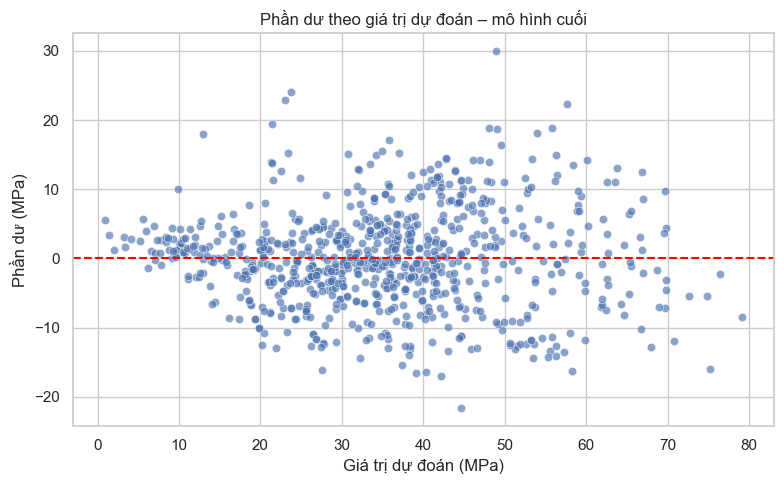

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.65, ax=ax)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_title("Phần dư theo giá trị dự đoán – mô hình cuối")
ax.set_xlabel("Giá trị dự đoán (MPa)")
ax.set_ylabel("Phần dư (MPa)")
fig.tight_layout()
fig.savefig(figures_dir / "residuals_vs_fitted.png", dpi=300, bbox_inches="tight")
plt.show()

Phần dư vẫn tập trung quanh 0 nhưng độ phân tán có xu hướng lớn hơn ở vùng cường độ dự đoán cao. Kết hợp với Breusch–Pagan (p < 0,001), giả định phương sai không đổi không được thỏa mãn.

### Q-Q plot của phần dư

Q-Q plot kiểm tra tính chuẩn: các điểm càng bám sát đường chéo thì phân phối phần dư càng gần chuẩn.

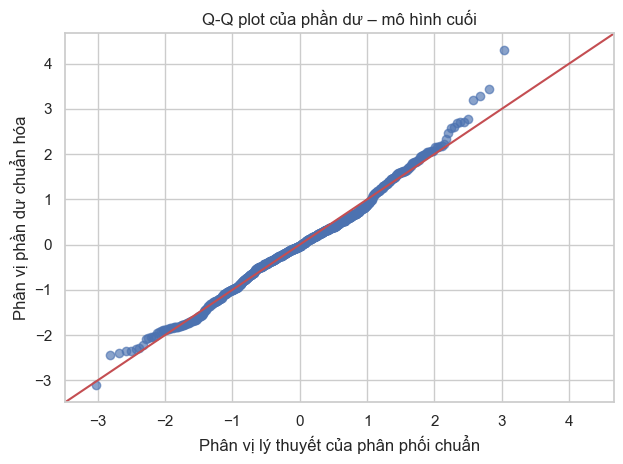

In [22]:
fig = sm.qqplot(residuals, line="45", fit=True, markerfacecolor="#4C72B0", alpha=0.65)
ax = fig.axes[0]
ax.set_title("Q-Q plot của phần dư – mô hình cuối")
ax.set_xlabel("Phân vị lý thuyết của phân phối chuẩn")
ax.set_ylabel("Phân vị phần dư chuẩn hóa")
fig.tight_layout()
fig.savefig(figures_dir / "residuals_qq.png", dpi=300, bbox_inches="tight")
plt.show()

Phần lớn điểm nằm gần đường chéo ở vùng giữa, nhưng hai đuôi lệch khỏi đường chuẩn. Kiểm định Jarque–Bera có p < 0,001, nên giả định phần dư chuẩn không hoàn toàn thỏa mãn.

### Histogram của phần dư

Histogram bổ sung góc nhìn về độ đối xứng, tâm và độ dày của hai đuôi phần dư.

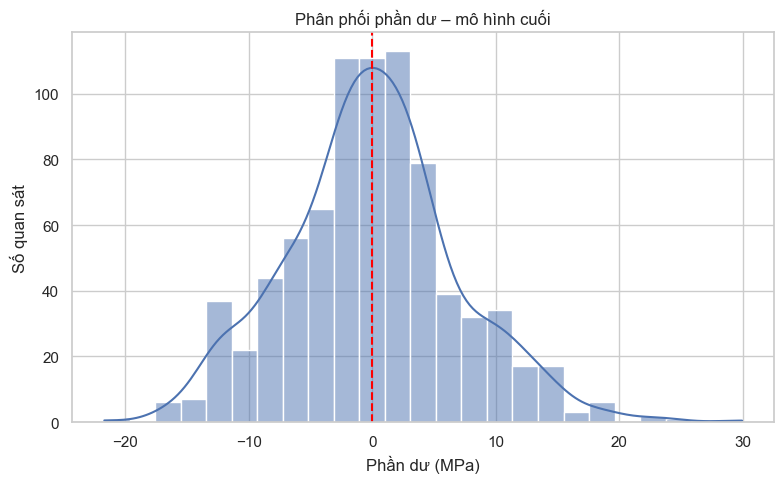

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(residuals, bins=25, kde=True, color="#4C72B0", ax=ax)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_title("Phân phối phần dư – mô hình cuối")
ax.set_xlabel("Phần dư (MPa)")
ax.set_ylabel("Số quan sát")
fig.tight_layout()
fig.savefig(figures_dir / "residuals_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

Histogram có tâm gần 0 nhưng hơi lệch phải và có đuôi dày hơn phân phối chuẩn. Đây là bằng chứng trực quan phù hợp với kết quả Jarque–Bera.

### Bảng VIF của mô hình cuối

Bảng này kiểm tra đa cộng tuyến sau khi đã bỏ `w_c`.

In [24]:
vif_final.to_csv(tables_dir / "final_model_vif.csv", index=False)
display(vif_final)

,variable,VIF
0,slag,7.1890
1,cement,7.1495
2,fine_agg,7.0739
3,water,6.9385
4,fly_ash,6.0143
5,coarse_agg,4.9986
6,superplasticizer,2.9366
7,log_age,1.0652


Tất cả VIF đều dưới 10; lớn nhất thuộc về `slag` và `cement`, xấp xỉ 7,19 và 7,15. Vì các thành phần cấp phối cùng tạo nên một hỗn hợp, một mức liên hệ vừa giữa chúng là khó tránh khỏi.

## 8. Trực quan hóa kết quả

### Giá trị dự đoán so với thực tế trên tập test

Đồ thị kiểm tra trực tiếp chất lượng dự báo. Điểm nằm trên đường $y=x$ là dự đoán hoàn hảo.

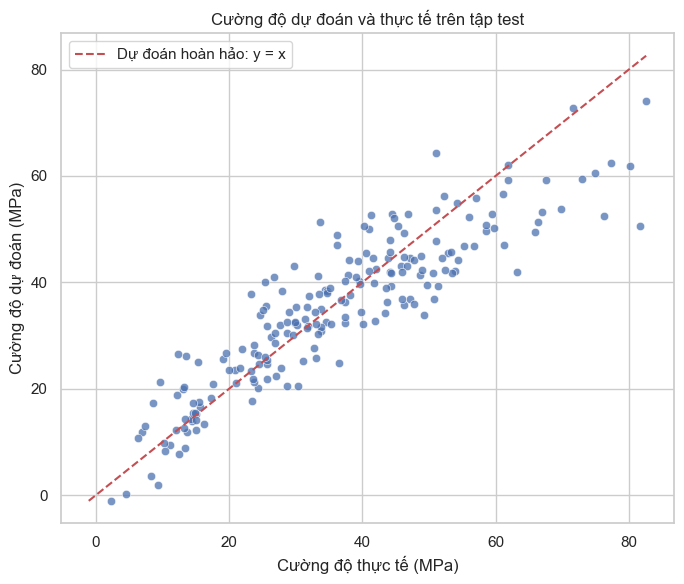

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(x=test_df["strength"], y=test_predictions, alpha=0.75, ax=ax)
line_min = min(test_df["strength"].min(), test_predictions.min())
line_max = max(test_df["strength"].max(), test_predictions.max())
ax.plot([line_min, line_max], [line_min, line_max], "r--", label="Dự đoán hoàn hảo: y = x")
ax.set_title("Cường độ dự đoán và thực tế trên tập test")
ax.set_xlabel("Cường độ thực tế (MPa)")
ax.set_ylabel("Cường độ dự đoán (MPa)")
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir / "predicted_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

Các điểm nhìn chung đi theo đường chéo, phù hợp với $R^2$ test khoảng 0,800. Tuy nhiên vẫn có một số sai số lớn và độ phân tán tăng ở vùng cường độ cao, nên không nên xem mô hình là chính xác cho mọi cấp phối.

### Biểu đồ hệ số của mô hình cuối

Hệ số thể hiện thay đổi MPa trên một đơn vị gốc của từng biến khi giữ các biến khác cố định. Vì thang đo khác nhau, độ dài cột không nên dùng trực tiếp để xếp hạng tầm quan trọng giữa các biến.

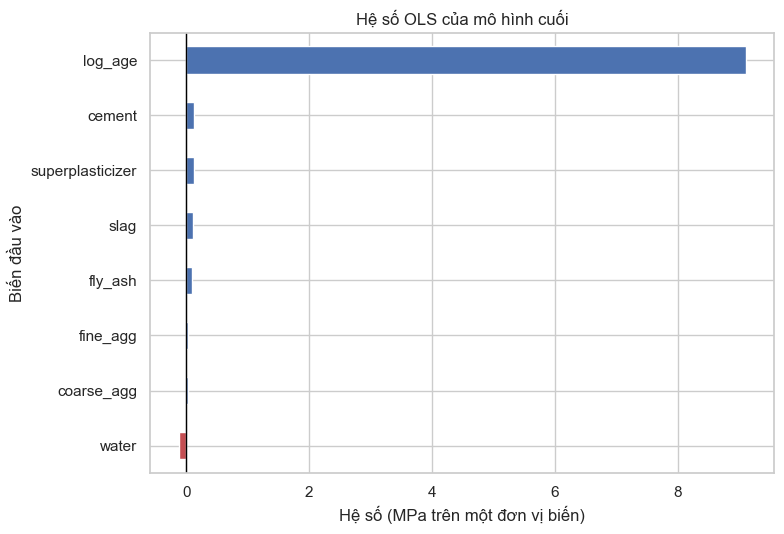

In [26]:
coefficient_series = final_model.params.drop("const").sort_values()

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ["#C44E52" if value < 0 else "#4C72B0" for value in coefficient_series]
coefficient_series.plot(kind="barh", color=colors, ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Hệ số OLS của mô hình cuối")
ax.set_xlabel("Hệ số (MPa trên một đơn vị biến)")
ax.set_ylabel("Biến đầu vào")
fig.tight_layout()
fig.savefig(figures_dir / "final_model_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

`log_age` có hệ số lớn do một đơn vị logarit không tương đương một ngày. Với các biến kg/m³, hệ số `cement`, `slag`, `fly_ash` dương và `water` âm; dấu này phù hợp với vai trò của chất kết dính và tỷ lệ nước/chất kết dính.

## 9. Diễn giải và nhận xét

Diễn giải hệ số của mô hình cuối (giữ các biến khác cố định):

- `cement`: tăng 1 kg/m³ xi măng liên hệ với **tăng khoảng 0,130 MPa**.
- `slag`: tăng 1 kg/m³ xỉ lò cao liên hệ với **tăng khoảng 0,110 MPa**.
- `fly_ash`: tăng 1 kg/m³ tro bay liên hệ với **tăng khoảng 0,092 MPa**.
- `water`: tăng 1 kg/m³ nước liên hệ với **giảm khoảng 0,123 MPa**. Điều này phù hợp với kiến thức vật liệu: quá nhiều nước thường làm tăng độ rỗng sau khi đóng rắn.
- `superplasticizer`: tăng 1 kg/m³ phụ gia siêu dẻo liên hệ với **tăng khoảng 0,129 MPa**, nhưng p-value khoảng 0,072 nên chưa đủ bằng chứng ở mức ý nghĩa 5%.
- `coarse_agg`: tăng 1 kg/m³ cốt liệu thô liên hệ với **tăng khoảng 0,027 MPa**.
- `fine_agg`: tăng 1 kg/m³ cốt liệu mịn liên hệ với **tăng khoảng 0,034 MPa**.
- `log_age`: tăng 1 đơn vị $\ln(age+1)$ liên hệ với **tăng khoảng 9,104 MPa**. Cách biến đổi log phản ánh cường độ phát triển nhanh ở tuổi sớm rồi chậm dần.

Ở mức ý nghĩa 5%, tất cả biến trừ `superplasticizer` có ý nghĩa thống kê. Hệ số chặn âm chủ yếu là tham số toán học; không nên diễn giải như một cấp phối thật khi mọi thành phần bằng 0.

Theo hệ số chuẩn hóa (tính ở cell tiếp theo), `cement` có độ lớn lớn nhất, sau đó là `log_age` và `slag`. Đây là mức liên hệ có điều kiện trong mô hình, không chứng minh quan hệ nhân quả.

### Hệ số chuẩn hóa để tham khảo tầm quan trọng

In [27]:
standardized_coefficients = (
    final_model.params[final_features]
    * train_df[final_features].std()
    / train_df["strength"].std()
).sort_values(key=np.abs, ascending=False)

display(standardized_coefficients.to_frame("he_so_chuan_hoa"))

,he_so_chuan_hoa
cement,0.8455
log_age,0.6228
slag,0.5912
fly_ash,0.3710
fine_agg,0.1696
water,-0.1649
coarse_agg,0.1280
superplasticizer,0.0477


`cement` có hệ số chuẩn hóa lớn nhất về trị tuyệt đối (khoảng 0,846), nhưng kết quả này vẫn chịu ảnh hưởng của tương quan giữa các thành phần cấp phối.

### Giới hạn của mô hình

- Mô hình chỉ mô tả quan hệ tuyến tính theo các biến đã biến đổi; các tương tác và quan hệ phi tuyến khác chưa được xét.
- Dữ liệu đến từ một bộ thí nghiệm/lab cụ thể, nên khả năng khái quát sang vật liệu, tiêu chuẩn dưỡng hộ hoặc phòng thí nghiệm khác còn hạn chế.
- Một số dòng có thể thuộc cùng một mẻ trộn và chỉ khác tuổi thử. Chia ngẫu nhiên theo dòng có thể đưa các quan sát liên quan vào cả train và test, làm giả định độc lập giữa hai tập không hoàn toàn chặt chẽ.
- Phần dư không hoàn toàn chuẩn và có phương sai thay đổi; do đó cần thận trọng khi dùng p-value, khoảng tin cậy và dự đoán ở vùng cực trị.
- Đây là phân tích quan sát; hệ số cho thấy liên hệ có điều kiện chứ không tự động chứng minh tác động nhân quả.

## 10. Lưu kết quả

### Lưu mô hình cuối

Đối tượng kết quả OLS được lưu bằng phương thức `results.save(...)` để có thể nạp lại cùng toàn bộ thông tin ước lượng.

In [28]:
results = final_model
model_path = models_dir / "ols_final.pkl"
results.save(model_path)
print(f"Đã lưu mô hình: {model_path}")

Đã lưu mô hình: c:\Users\Phong\Desktop\concrete-compressive-strength-analysis\models\ols_final.pkl


File mô hình chứa hệ số, phần dư và các thống kê của mô hình cuối.

### Lưu bảng hệ số

In [29]:
confidence_intervals = final_model.conf_int()
coefficient_table = pd.DataFrame({
    "variable": final_model.params.index,
    "coefficient": final_model.params.values,
    "std_error": final_model.bse.values,
    "t_statistic": final_model.tvalues.values,
    "p_value": final_model.pvalues.values,
    "ci_95_low": confidence_intervals[0].values,
    "ci_95_high": confidence_intervals[1].values,
})

coefficient_table.to_csv(tables_dir / "regression_coefficients.csv", index=False)
display(coefficient_table)

,variable,coefficient,std_error,t_statistic,p_value,ci_95_low,ci_95_high
0,const,-74.1061,20.1951,-3.6695,0.0003,-113.7481,-34.4642
1,cement,0.1303,0.0064,20.4831,0.0000,0.1178,0.1428
2,slag,0.1100,0.0077,14.2828,0.0000,0.0949,0.1252
3,fly_ash,0.0924,0.0094,9.8001,0.0000,0.0739,0.1109
4,water,-0.1227,0.0303,-4.0549,0.0001,-0.1821,-0.0633
5,superplasticizer,0.1286,0.0713,1.8043,0.0716,-0.0113,0.2684
6,coarse_agg,0.0265,0.0072,3.7071,0.0002,0.0125,0.0406
7,fine_agg,0.0336,0.0081,4.1294,0.0000,0.0176,0.0495
8,log_age,9.1039,0.2329,39.0886,0.0000,8.6467,9.5611


Bảng hệ số đã được lưu cùng sai số chuẩn, thống kê t, p-value và khoảng tin cậy 95% để dùng trong báo cáo.

### Dự đoán thử sau khi nạp lại mô hình

Ba cấp phối giả định được nhập bằng các biến thô. `log_age` và `w_c` được tự tính; sau đó chỉ các cột đúng với mô hình đã lưu mới được đưa vào dự đoán.

In [30]:
loaded_results = sm.load(model_path)

new_mixes = pd.DataFrame([
    {"cement": 350, "slag": 50, "fly_ash": 100, "water": 175, "superplasticizer": 8, "coarse_agg": 1000, "fine_agg": 750, "age": 28},
    {"cement": 420, "slag": 80, "fly_ash": 0, "water": 168, "superplasticizer": 10, "coarse_agg": 1020, "fine_agg": 690, "age": 90},
    {"cement": 300, "slag": 0, "fly_ash": 120, "water": 190, "superplasticizer": 5, "coarse_agg": 980, "fine_agg": 780, "age": 7},
])

new_mixes["log_age"] = np.log1p(new_mixes["age"])
new_mixes["w_c"] = new_mixes["water"] / new_mixes["cement"]

prediction_X = sm.add_constant(new_mixes[final_features], has_constant="add")
new_mixes["predicted_strength_MPa"] = loaded_results.predict(prediction_X)

display(new_mixes)

,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,log_age,w_c,predicted_strength_MPa
0,350,50,100,175,8,1000,750,28,3.3673,0.5000,48.1735
1,420,80,0,168,10,1020,690,90,4.5109,0.4000,61.4023
2,300,0,120,190,5,980,780,7,2.0794,0.6333,24.5290


Các dự đoán chỉ mang tính minh họa trong phạm vi dữ liệu đã quan sát. `w_c` vẫn được tính từ đầu vào thô để kiểm tra cấp phối, nhưng không đưa vào ma trận cuối vì đã bị loại ở bước VIF.

## Kết luận

Biến đổi logarit của tuổi cải thiện rõ rệt mô hình tuyến tính. Mô hình cuối giải thích khoảng 80% biến thiên trên tập test và có RMSE khoảng 7,72 MPa. Tuy nhiên, phương sai phần dư không đồng nhất và phần dư không hoàn toàn chuẩn, nên cần thận trọng khi suy luận thống kê và không nên ngoại suy ra ngoài phạm vi cấp phối của bộ dữ liệu.